In [1]:
!pip install torch torchvision matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.4/253.4 KB 51.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 244.6 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 KB 335.2 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 67.1 kB/s eta 0:00:00a 0:00:02
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
You should consider upgrading via the '/Users/akhileshkumar/.pyenv/versions/3.10.5/bin/python3.10 -m pip install --upgrade pip' command.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),  
                         (0.5, 0.5, 0.5))  
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64,
                                            shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64,
                                            shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')

100%|██████████| 170M/170M [05:14<00:00, 541kB/s]    


Training samples : 50000
Test samples     : 10000


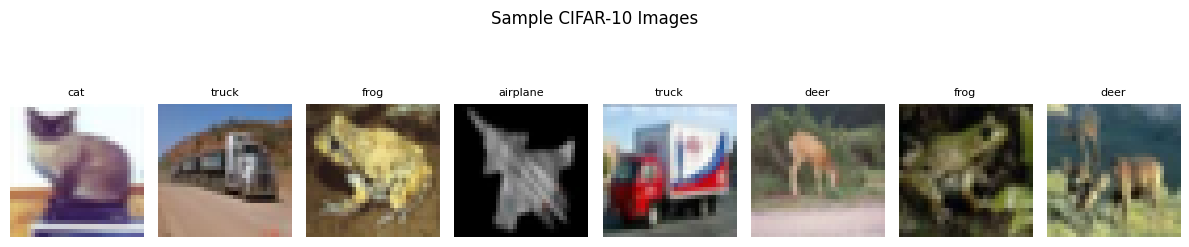

In [4]:
def imshow(img):
    """Un-normalize and display an image."""
    img = img / 2 + 0.5   
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    imshow(images[i])
    plt.title(classes[labels[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                      

            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                        

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                          
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 10)   
        )

    def forward(self, x):
        x = self.features(x)         
        x = x.view(x.size(0), -1)  
        x = self.classifier(x)       
        return x

model = CIFAR10_CNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS = 15
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        
        outputs = model(images)  
        loss = criterion(outputs, labels) 
        loss.backward()             
        optimizer.step()         

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    test_loss = val_loss / len(test_loader)
    test_acc  = 100. * val_correct / val_total

    train_losses.append(train_loss); test_losses.append(test_loss)
    train_accs.append(train_acc);   test_accs.append(test_acc)

    scheduler.step()

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | '
          f'Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%')

print('\nTraining complete!')

Epoch [ 1/15] Train Loss: 1.3575 Acc: 50.8% | Test Loss: 1.0038 Acc: 64.1%
Epoch [ 2/15] Train Loss: 1.0339 Acc: 63.5% | Test Loss: 0.8988 Acc: 68.8%
Epoch [ 3/15] Train Loss: 0.9062 Acc: 68.3% | Test Loss: 0.8155 Acc: 71.0%
Epoch [ 4/15] Train Loss: 0.8307 Acc: 70.8% | Test Loss: 0.7404 Acc: 74.5%
Epoch [ 5/15] Train Loss: 0.7674 Acc: 73.2% | Test Loss: 0.7111 Acc: 75.2%
Epoch [ 6/15] Train Loss: 0.6635 Acc: 77.1% | Test Loss: 0.6469 Acc: 77.3%
Epoch [ 7/15] Train Loss: 0.6233 Acc: 78.5% | Test Loss: 0.6511 Acc: 77.5%
Epoch [ 8/15] Train Loss: 0.5968 Acc: 79.1% | Test Loss: 0.6209 Acc: 78.3%
Epoch [ 9/15] Train Loss: 0.5733 Acc: 80.0% | Test Loss: 0.5993 Acc: 78.9%
Epoch [10/15] Train Loss: 0.5511 Acc: 80.7% | Test Loss: 0.6033 Acc: 79.0%
Epoch [11/15] Train Loss: 0.4919 Acc: 82.6% | Test Loss: 0.5613 Acc: 80.5%
Epoch [12/15] Train Loss: 0.4736 Acc: 83.3% | Test Loss: 0.5655 Acc: 80.4%
Epoch [13/15] Train Loss: 0.4580 Acc: 83.9% | Test Loss: 0.5644 Acc: 80.5%
Epoch [14/15] Train Loss:

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs, test_losses,  'r-o', label='Test Loss',  markersize=4)
ax1.set_title('Loss over Epochs');  ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, train_accs, 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs, test_accs,  'r-o', label='Test Acc',  markersize=4)
ax2.set_title('Accuracy over Epochs'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.suptitle('CIFAR-10 CNN Training', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CIFAR-10')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images.to(device))
_, predicted = outputs.max(1)

plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    imshow(images[i])
    color = 'green' if predicted[i].item() == labels[i].item() else 'red'
    plt.title(f'Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}',
              fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=11)
plt.tight_layout()
plt.show()